# Create AAV6-ML plots for report for internship in AG Grimm
Author: Kolja Hildenbrand

Created: 01/04/2026

## 1. Packages

In [18]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import re
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import product
from matplotlib_venn import venn2

## 2. Create Paths

In [9]:
#---------------------------------
#---------------------------------
#---------------------------------

#general Path

general_dir = Path('/Users/kollybook/Library/Mobile Documents/com~apple~CloudDocs/Kolja_Hildenbrand/Uni/Master_Infectious_Diseases/Grimm_internship/Report_Grimm/Data') # <----- Hier den Server Path anpassen
os.makedirs(general_dir, exist_ok=True)

#---------------------------------
#---------------------------------
#---------------------------------

# Path for NGS data
NGS_dir = general_dir/'NGS_data'
os.makedirs(NGS_dir, exist_ok=True)

# Path for tables
tables_dir = general_dir/'Tables'
os.makedirs(tables_dir, exist_ok=True)

#Path for plots
plots_dir = general_dir/'Figures'
os.makedirs(plots_dir, exist_ok=True)

## 3. Define Functions
### 3.1. Helper functions

In [6]:
# read csv files
def read_csv_file (path, file_name):
    df = pd.read_csv(path / f"{file_name}.csv")
    return df

In [7]:
# extract list information from table
def extract_info(table, *columns):
    results = []
    
    for col in columns:
        if col not in table.columns:
            raise ValueError(f"Column '{col}' not found in table")
        
        unique_vals = (
            table[col]
            .dropna()
            .unique()
            .tolist()
        )
        
        results.append(sorted(unique_vals))
    
    return tuple(results)
    
    

### 3.2. Script Functions

In [61]:
input_lib = dict_library['liver']['gDNA']
df = df_long_table[
        (df_long_table["Tissue"] == 'liver') &
        (df_long_table["Extraction_type"] == 'gDNA')
    ][['AA_sequence', 'Mouse_ID', 'Proportion', 'Cum_prop', 'Log2_enrichment', 'Pseudo']].copy()

In [62]:
input_lib["Data"] = 'input_library'
df = df.rename(columns = {'Mouse_ID': 'Data'})

In [63]:
display (input_lib, df)

,AA_sequence,Count,Pseudo,Proportion,Cum_prop,Data
0,DDAGADG,30237.0,0,4.483036e-04,0.000448,input_library
1,DDAAADG,27982.0,0,4.148702e-04,0.000863,input_library
2,DDAGAEG,27889.0,0,4.134914e-04,0.001277,input_library
3,DDAAAEG,27861.0,0,4.130762e-04,0.001690,input_library
4,GDDAAEG,22253.0,0,3.299302e-04,0.002020,input_library
...,...,...,...,...,...,...
3296797,HDAXVGG,1.0,1,1.482632e-08,1.000000,input_library
3296798,SENTVDE,1.0,1,1.482632e-08,1.000000,input_library
3296799,HDAXVET,1.0,1,1.482632e-08,1.000000,input_library
3296800,DRXGAAG,1.0,1,1.482632e-08,1.000000,input_library


,AA_sequence,Data,Proportion,Cum_prop,Log2_enrichment,Pseudo
55998096,KKDAPAD,f1,4.562691e-05,0.862463,9.265580,0
55998097,GDKAPGV,f1,7.162406e-06,0.675927,8.916140,0
55998098,EVGEGGQ,f1,6.311422e-06,0.573811,8.733660,0
55998099,GETLGAE,f1,5.290240e-06,0.753107,8.479028,0
55998100,HDEEGQD,f1,1.550206e-05,0.826047,8.445120,0
...,...,...,...,...,...,...
75778903,GDDAPGD,m3,1.413539e-08,0.642520,-9.300070,1
75778904,DEDGEAG,m3,1.413539e-08,0.308377,-9.300070,1
75778905,DDDAIGG,m3,1.413539e-08,0.180374,-9.307254,1
75778906,DDDVEDG,m3,1.413539e-08,0.202015,-9.441714,1


In [71]:
combined = pd.concat([input_lib, df], axis=0, ignore_index=True)
combined

,AA_sequence,Count,Pseudo,Proportion,Cum_prop,Data,Log2_enrichment
0,DDAGADG,30237.0,0,4.483036e-04,0.000448,input_library,NaN
1,DDAAADG,27982.0,0,4.148702e-04,0.000863,input_library,NaN
2,DDAGAEG,27889.0,0,4.134914e-04,0.001277,input_library,NaN
3,DDAAAEG,27861.0,0,4.130762e-04,0.001690,input_library,NaN
4,GDDAAEG,22253.0,0,3.299302e-04,0.002020,input_library,NaN
...,...,...,...,...,...,...,...
23077609,GDDAPGD,NaN,1,1.413539e-08,0.642520,m3,-9.300070
23077610,DEDGEAG,NaN,1,1.413539e-08,0.308377,m3,-9.300070
23077611,DDDAIGG,NaN,1,1.413539e-08,0.180374,m3,-9.307254
23077612,DDDVEDG,NaN,1,1.413539e-08,0.202015,m3,-9.441714


In [90]:
# Function to create Histogram of sample proportion vs input proportion

def distribution_histogram (table, tissue, extraction, column, save=False, output_path=None):
    
    x_min = table[column].min() 
    x_max = table[column].max()
    
    input_library = dict_library[tissue][extraction].copy()
    df = table[
        (table["Tissue"] == tissue) &
        (table["Extraction_type"] == extraction)
    ][['AA_sequence', 'Mouse_ID', 'Proportion', 'Cum_prop', 'Log2_enrichment', 'Pseudo']].copy()
    df = df.rename(columns = {'Mouse_ID': 'Data'})
    df = pd.concat([input_lib, df], axis=0, ignore_index=True)

    df = df[df[column].notna()].copy()

    bin_edges = np.logspace(np.log10(x_min), np.log10(x_max), 100)

    sns.set_style("white")
    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10
    })

    fig, ax = plt.subplots(figsize=(7.5, 5.2))
    
    present_data = df['Data'].unique()
    for data in present_data:
        sub = df[df["Data"] == data]

        ax.hist(
            sub[column],
            bins=bin_edges,
            alpha=0.35,
            label=data,
            edgecolor="none"
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(x_min, x_max)
    
    ax.set_xlabel("Variant proportion in sample")
    ax.set_ylabel("Number of AA sequences")
    ax.set_title(f"{extraction} {tissue}: distribution of AA-sequence proportions")

    # cleaner legend
    ax.legend(title="Mouse ID", frameon=False, ncol=2)

    
    sns.despine()
    plt.tight_layout()

    if save:
        if output_path is None:
            raise ValueError("Please provide output_path when save=True")
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

In [104]:
# Function to create Log2_enrichment distribution ecdf figure of one tissue/ext type with hue between mouse_ID

def distribution_ecdf(table, tissue, extraction, column, save=False, output_path=None):

    x_min = table[column].min() 
    x_max = table[column].max()
    
    df = table[
        (table["Tissue"] == tissue) &
        (table["Extraction_type"] == extraction)
    ].copy()

    df = df[df[column].notna()].copy()
    
    sns.set_style("white")
    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "legend.fontsize": 10
    })

    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    sns.ecdfplot(
        data=df,
        x=column,
        hue="Mouse_ID",
        ax=ax,
        linewidth=2
    )
    
    # reference line no enrichment
    ax.axvline(
        0, 
        linestyle="--", 
        linewidth=1.5, color="red", alpha=0.9
    )
    
    mean_val = df[column].mean()
    ax.axvline(
        mean_val, 
        linestyle="--", 
        linewidth=1.5, 
        color="blue", 
        alpha=0.9
    )
        
    ax.set_xlim(x_min, x_max)
    
    ax.set_xlabel(f"Variant {column}")
    ax.set_ylabel("Cumulative fraction of AA sequences")
    ax.set_title(f"{extraction} {tissue}\n cumulative distribution of {column}\n Mean = {mean_val:.2f}")

    ax.legend(title="Mouse ID", loc="upper right", frameon=False, ncol=2)
    
    sns.despine()
    plt.tight_layout()

    if save:
        if output_path is None:
            raise ValueError("Please provide output_path when save=True")
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()



In [97]:
def distribution_kde(table, tissue, extraction, column, save=False, output_path=None):

    input_library = dict_library[tissue][extraction].copy()

    df = table[
        (table["Tissue"] == tissue) &
        (table["Extraction_type"] == extraction)
    ][['AA_sequence', 'Mouse_ID', 'Proportion', 'Cum_prop', 'Log2_enrichment', 'Pseudo']].copy()

    df = df.rename(columns={'Mouse_ID': 'Data'})

    # 👉 concat statt merge
    df = pd.concat([input_library, df], axis=0, ignore_index=True)

    # remove NaN + zeros (wichtig für log!)
    df = df[df[column].notna()].copy()
    df = df[df[column] > 0].copy()

    # 👉 log-transform für KDE
    df["log_value"] = np.log10(df[column])

    sns.set_style("white")
    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "legend.fontsize": 10
    })

    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    # KDE plot
    sns.kdeplot(
        data=df,
        x="log_value",
        hue="Data",
        common_norm=False,   # wichtig für Vergleich!
        fill=True,
        alpha=0.3,
        linewidth=1.5,
        ax=ax
    )

    # Achsen zurück in log-space beschriften
    xticks = np.arange(np.floor(df["log_value"].min()), np.ceil(df["log_value"].max()))
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"$10^{{{int(x)}}}$" for x in xticks])

    ax.set_xlabel("Variant proportion")
    ax.set_ylabel("Density")
    ax.set_title(f"{extraction} {tissue}: distribution of AA-sequence proportions (KDE)")

    ax.legend(title="Data", frameon=False)

    sns.despine()
    plt.tight_layout()

    if save:
        if output_path is None:
            raise ValueError("Please provide output_path when save=True")
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

## 4. Script
### 4.1. Load CSV Files

In [10]:
%%time
#load long table
df_long_table = read_csv_file(tables_dir / 'summary', "df_long_table_metadata")

# load pooled table
df_pooled = read_csv_file(tables_dir / 'summary', "df_pooled_table")

CPU times: user 38.8 s, sys: 6.42 s, total: 45.3 s
Wall time: 48 s


### 4.2. Extract information from table

In [11]:
SAMPLE, EXT, TISSUE, SEX, MOUSE_ID = extract_info(
    df_long_table, 
    'Sample', 
    'Extraction_type',
    "Tissue", 
    'Sex', 
    'Mouse_ID'
)

### 4.3. Load tissue/ext specific librarys

In [13]:
dict_library = {}
for tissue, ext in product(TISSUE, EXT):
    df = read_csv_file(tables_dir/tissue, f'df_input_library_for_{ext}_{tissue}')
    dict_library.setdefault(tissue,{})[ext] = df

# Load library to forr corr with special library
df_raw_input =  read_csv_file(tables_dir, 'df_input_lib')

### 4.5. ECDF Log2 distribution between samples

/var/folders/h4/yjbr0z293zqfcvqq3065dmxm0000gn/T/ipykernel_52319/2990695169.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Mouse ID", loc="upper right", frameon=False, ncol=2)


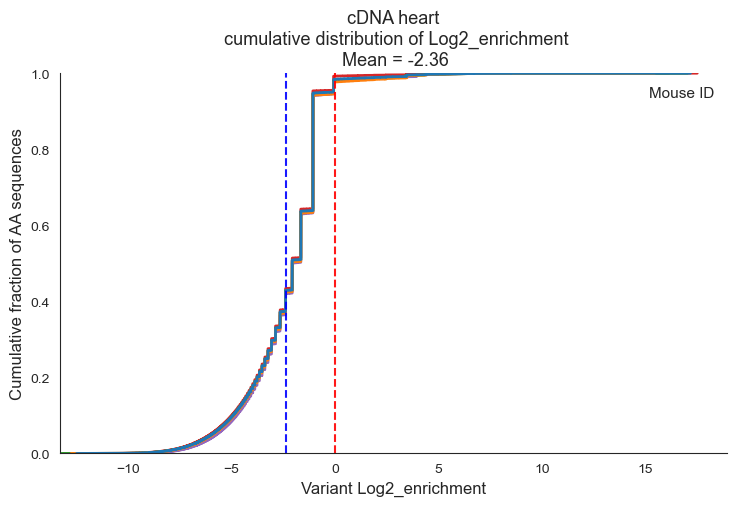

/var/folders/h4/yjbr0z293zqfcvqq3065dmxm0000gn/T/ipykernel_52319/2990695169.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Mouse ID", loc="upper right", frameon=False, ncol=2)


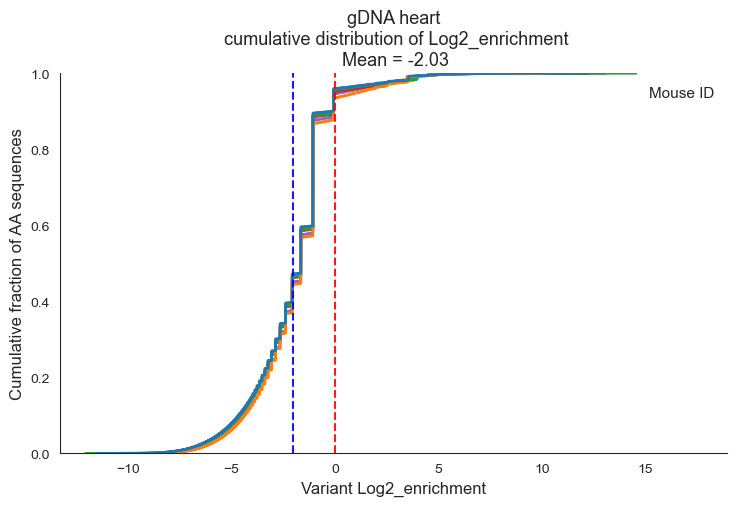

/var/folders/h4/yjbr0z293zqfcvqq3065dmxm0000gn/T/ipykernel_52319/2990695169.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Mouse ID", loc="upper right", frameon=False, ncol=2)


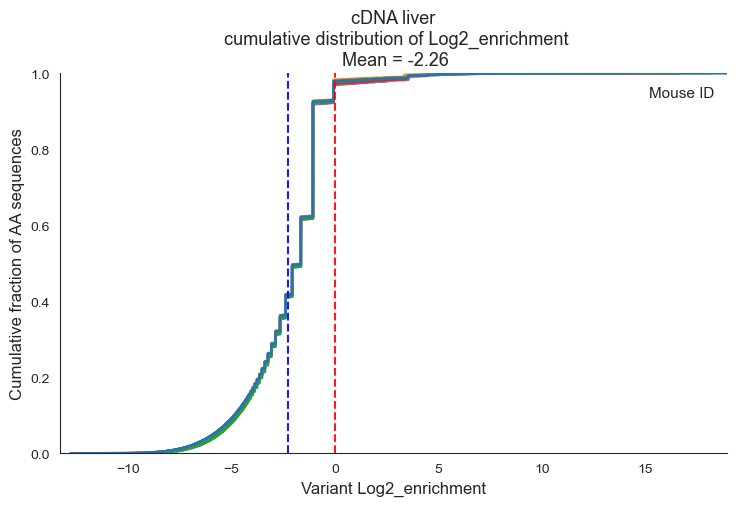

/var/folders/h4/yjbr0z293zqfcvqq3065dmxm0000gn/T/ipykernel_52319/2990695169.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Mouse ID", loc="upper right", frameon=False, ncol=2)


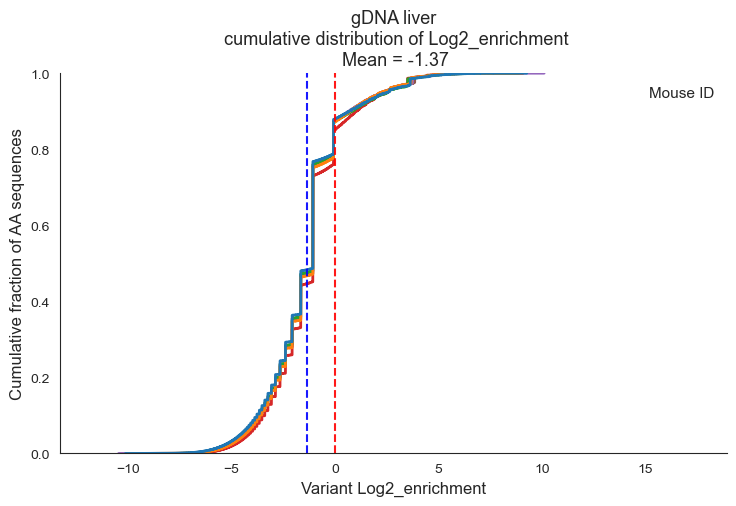

CPU times: user 48.4 s, sys: 15.5 s, total: 1min 3s
Wall time: 1min 18s


In [105]:
%%time
for tissues, exts in product (TISSUE, EXT):
    distribution_ecdf (df_long_table, tissues, exts, 'Log2_enrichment');

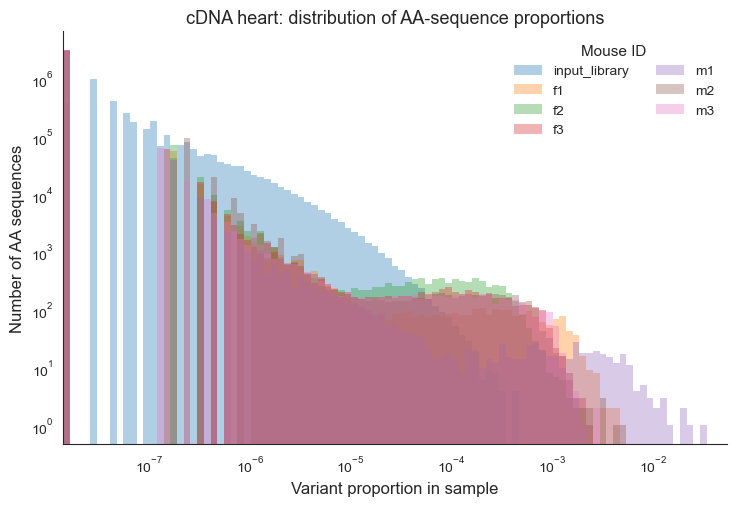

In [100]:
distribution_histogram (df_long_table, 'heart', 'cDNA', 'Proportion')

/var/folders/h4/yjbr0z293zqfcvqq3065dmxm0000gn/T/ipykernel_52319/13583069.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Data", frameon=False)


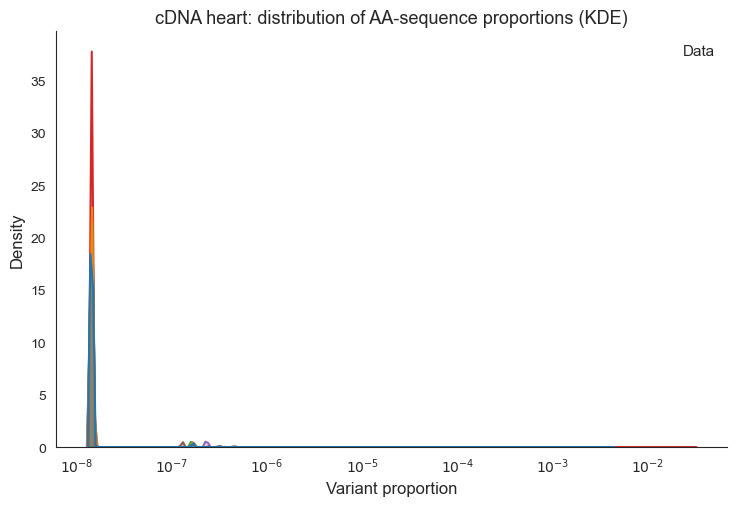

In [98]:
distribution_kde (df_long_table, 'heart', 'cDNA', 'Proportion')